In [67]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

from scipy.sparse import diags
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

from matplotlib.animation import FuncAnimation

from IPython.display import HTML

# Fonction mathematique sech

In [68]:
def sech(x):
    return 1 / np.cosh(x)

# Solution analytique

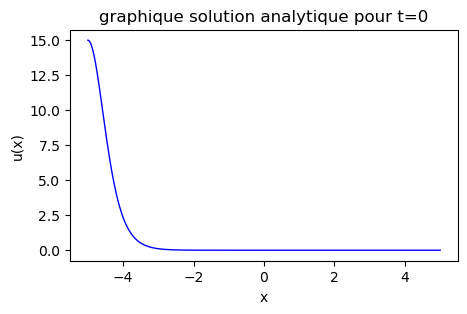

In [69]:
# ----------------------------------------
# Solution
# ----------------------------------------
# x : position 
# t : temps
def sol_an(x, t, eps, mu, c, x0):
    xi = x-c*t
    return 3*c/eps * sech(1/2 * math.sqrt(c/mu) * (xi-x0))**2

# ----------------------------------------
# Graphique pour la solution analytique
# ----------------------------------------
x = np.linspace(-5, 5, 1000)
u_t0 = sol_an(x, 0, 0.2, 0.1, 1, -5)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, u_t0, color='blue', linewidth=1)
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("graphique solution analytique pour t=0")
plt.show()

# Mise en place du schéma de Crank-Nikolson

In [70]:
# ----------------------------------------
# Schéma de Crank-Nikolson avec résolution du système 
# ----------------------------------------
def sol_ck (x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0) :
    #x_debut : point de depart du maillage en x
    #x_fin : point de fin du maillage en x
    #Tf : temps de fin du maillage
    #Nx : nombre de subdivision en X
    #Nt : nombre de subdivision en temps

    t = 0 #temps de début

    #Pas du maillage
    hx = (x_fin - x_debut)/(Nx-1)
    ht = Tf/Nt
    
    #Constantes 
    alpha = (mu * ht) / (hx**3)
    beta = (eps * ht) / hx

    x = np.linspace(x_debut, x_fin, Nx)
    #Creation des matrices / vect
    Un = np.zeros((Nt,Nx))
    #Creation des matrices / vect
    Un[0,:] = sol_an(x, 0, eps, mu, c, x0)
    matA = np.zeros ((Nx,Nx))
    MatB = np.zeros ((Nx,Nx))


    #Cond. de Dirichlet Un+1 = Un pour i = 0,1 & i = N-1,N
    matA[0,0] = matA[1,1] = 1 
    MatB[0,0] = MatB[1,1] = 1
    matA[Nx-2, Nx-2] = matA[Nx-1, Nx-1] = 1
    MatB[Nx-2, Nx-2] = MatB[Nx-1, Nx-1] = 1
     
    
    for i in range(1,Nt) : #a chaque temps
        gamma = (alpha / 2) - (beta / 4) * Un[i-1, :]

        for j in range(2, Nx - 2):
            matA[j, j-2] = -alpha / 4
            matA[j, j-1] = gamma[j]
            matA[j, j]   = 1
            matA[j, j+1] = -gamma[j]
            matA[j, j+2] = alpha / 4
            
            MatB[j, j-2] = alpha / 4
            MatB[j, j-1] = -gamma[j]
            MatB[j, j]   = 1
            MatB[j, j+1] = gamma[j]
            MatB[j, j+2] = -alpha / 4
            
        # b = B * Un
        b = np.dot(MatB, Un[i-1,:]) # Moins performant de passer MatB en sparse
        
        # Résolution A * Un+1 = b
        Un[i, :] = np.linalg.solve(matA, b)

    return Un , x

In [71]:
# ----------------------------------------
# Schéma de Crank-Nikolson avec résolution du système pour une matrice sparse
# ----------------------------------------
def sol_ck_sparse (x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0) :
    #x_debut : point de depart du maillage en x
    #x_fin : point de fin du maillage en x
    #Tf : temps de fin du maillage
    #Nx : nombre de subdivision en X
    #Nt : nombre de subdivision en temps

    t = 0 #temps de début

    #Pas du maillage
    hx = (x_fin - x_debut)/(Nx-1)
    ht = Tf/Nt
    
    #Constantes 
    alpha = (mu * ht) / (hx**3)
    beta = (eps * ht) / hx

    x = np.linspace(x_debut, x_fin, Nx)
    Un = np.zeros((Nt,Nx))
    #Creation des matrices / vect
    Un[0,:] = sol_an(x, 0, eps, mu, c, x0)

    diag_0 = np.ones(Nx) #diag princpale

    # Creation des diagonales des matrices, m2 = moins 2 (decalage -2), p2 = plus 2
    diag_m2A = np.zeros(Nx - 2)
    diag_p2A = np.zeros(Nx - 2)
    diag_m2B = np.zeros(Nx - 2)
    diag_p2B = np.zeros(Nx - 2)

    #Cond. de Dirichlet Un+1 = Un pour i = 0,1 & i = N-1,N
    diag_m2A[0:Nx-4] = -alpha / 4
    diag_p2A[2:Nx-2] = alpha / 4
    
    diag_m2B[0:Nx-4] = alpha / 4
    diag_p2B[2:Nx-2] = -alpha / 4



    for i in range(1,Nt) : # a chaque temps
        gamma = (alpha / 2) - (beta / 4) * Un[i-1,:]

        #diag decalage + - 1 a recalculer a chaque boucle
        diag_m1A = np.zeros(Nx - 1)
        diag_p1A = np.zeros(Nx - 1)
        diag_m1B = np.zeros(Nx - 1)
        diag_p1B = np.zeros(Nx - 1)


        diag_m1A[1:Nx-3] = gamma[2:Nx-2]
        diag_p1A[2:Nx-2] = -gamma[2:Nx-2]
        
        diag_m1B[1:Nx-3] = -gamma[2:Nx-2]
        diag_p1B[2:Nx-2] = gamma[2:Nx-2]

        # Stockage sparse de A        
        matA_sp = diags([diag_m2A, diag_m1A, diag_0, diag_p1A, diag_p2A], 
                        [-2, -1, 0, 1, 2], format='csr')
        
        MatB_sp = diags([diag_m2B, diag_m1B, diag_0, diag_p1B, diag_p2B], 
                        [-2, -1, 0, 1, 2], format='csr')
        
        # b = B * Un
        b = MatB_sp.dot(Un[i-1, :]) 

        # Résolution A * Un+1 = b
        Un[i, :] = spsolve(matA_sp, b)        

    return Un , x


# def sol_ck_sparse(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0):
#     hx = (x_fin - x_debut) / (Nx - 1)
#     ht = Tf / Nt
    
#     alpha = (mu * ht) / (hx**3)
#     beta = (eps * ht) / hx

#     x = np.linspace(x_debut, x_fin, Nx)
#     Un = np.zeros((Nt, Nx))
    
#     # Transmission des paramètres à la solution analytique
#     Un[0, :] = sol_an(x, 0, x0, c, eps, mu) 
    
#     matA = np.zeros((Nx, Nx))
#     MatB = np.zeros((Nx, Nx))

#     matA[0,0] = matA[1,1] = 1 
#     MatB[0,0] = MatB[1,1] = 1
#     matA[Nx-2, Nx-2] = matA[Nx-1, Nx-1] = 1
#     MatB[Nx-2, Nx-2] = MatB[Nx-1, Nx-1] = 1
     
#     for i in range(1, Nt): 
#         gamma = (alpha / 2) - (beta / 4) * Un[i-1, :]

#         for j in range(2, Nx - 2):
#             matA[j, j-2] = -alpha / 4
#             matA[j, j-1] = gamma[j]
#             matA[j, j]   = 1
#             matA[j, j+1] = -gamma[j]
#             matA[j, j+2] = alpha / 4
            
#             MatB[j, j-2] = alpha / 4
#             MatB[j, j-1] = -gamma[j]
#             MatB[j, j]   = 1
#             MatB[j, j+1] = gamma[j]
#             MatB[j, j+2] = -alpha / 4

#         matA_sp = csr_matrix(matA)
#         b = np.dot(MatB, Un[i-1, :]) 
#         Un[i, :] = spsolve(matA_sp, b)

#     return Un, x

In [72]:
def UEX (x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0):
    #x_debut : point de depart du maillage en x
    #x_fin : point de fin du maillage en x
    #Tf : temps de fin du maillage
    #Nx : nombre de subdivision en X
    #Nt : nombre de subdivision en temps

    t = 0 #temps de début

    x = np.linspace(x_debut, x_fin, Nx)
    Un = np.zeros((Nt,Nx))

    for i in range(Nt) :
        Un[i,:] = sol_an(x, i * Tf / Nt, eps, mu, c, x0)

    return Un, x
    

# Calcul des solutions & mesure des temps de Calcul

In [ ]:
c = 1.0       # Vitesse du soliton
eps = 0.2
mu = 0.1
x0 = -5.0     # Point de départ de la vague

x_debut = -15.0
x_fin = 15.0
Tf = 10.0   

Nx = 4000     
Nt = 4000     

In [88]:
# Matrice pleine
# start_sol_ck = time.perf_counter()
# U_numerique_final, x_num = sol_ck(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0)
# end_sol_ck = time.perf_counter()

In [73]:
# Matrice sparse
start_sol_ck_sp = time.perf_counter()
U_numerique_final_sp, x_num_sp = sol_ck_sparse(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0)
end_sol_ck_sp = time.perf_counter()

In [74]:
# Calcul de la théorie exacte au temps final pour comparaison
start_sol_an = time.perf_counter()
U_ex, x_ex = UEX(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0)
end_sol_an = time.perf_counter()
U_analytique = sol_an(x_num_sp, Tf, eps, mu, c, x0)

In [89]:
# Temps de calculs
# print(f"Temps d'exécution solution numérique Matrice pleine : {end_sol_ck - start_sol_ck} secondes")
print(f"Temps d'exécution solution numérique Matrice sparse : {end_sol_ck_sp - start_sol_ck_sp} secondes")
print(f"Temps d'exécution solution analytique : {end_sol_an - start_sol_an} secondes")

Temps d'exécution solution numérique Matrice sparse : 9.521614400000544 secondes
Temps d'exécution solution analytique : 0.22387609999987035 secondes


In [19]:
U_ex

array([[1.10803600e-12, 1.29818472e-12, 1.52096465e-12, ...,
        2.80880596e-26, 2.39739234e-26, 2.04623962e-26],
       [1.05114963e-12, 1.23153615e-12, 1.44287859e-12, ...,
        2.96081360e-26, 2.52713500e-26, 2.15697851e-26],
       [9.97183794e-13, 1.16830931e-12, 1.36880146e-12, ...,
        3.12104763e-26, 2.66389910e-26, 2.27371039e-26],
       ...,
       [2.39675960e-26, 2.80806464e-26, 3.28995324e-26, ...,
        1.29852744e-12, 1.10832852e-12, 9.45988557e-13],
       [2.27371039e-26, 2.66389910e-26, 3.12104763e-26, ...,
        1.36880146e-12, 1.16830931e-12, 9.97183794e-13],
       [2.15697851e-26, 2.52713500e-26, 2.96081360e-26, ...,
        1.44287859e-12, 1.23153615e-12, 1.05114963e-12]], shape=(600, 600))

In [20]:
U_numerique_final_sp

array([[ 1.10803600e-12,  1.29818472e-12,  1.52096465e-12, ...,
         2.80880596e-26,  2.39739234e-26,  2.04623962e-26],
       [ 1.10803600e-12,  1.29818472e-12,  1.45041222e-12, ...,
        -1.32740211e-21,  2.39739234e-26,  2.04623962e-26],
       [ 1.10803600e-12,  1.29818472e-12,  1.40523146e-12, ...,
        -3.61303502e-20,  2.39739234e-26,  2.04623962e-26],
       ...,
       [ 1.10803600e-12,  1.29818472e-12, -1.56962503e-03, ...,
         4.65811493e-03,  2.39739234e-26,  2.04623962e-26],
       [ 1.10803600e-12,  1.29818472e-12, -1.41710930e-03, ...,
         4.76575070e-03,  2.39739234e-26,  2.04623962e-26],
       [ 1.10803600e-12,  1.29818472e-12, -1.06856852e-03, ...,
         4.42486512e-03,  2.39739234e-26,  2.04623962e-26]],
      shape=(600, 600))

# Comparaison des résultats numérique et de la solution analytique (Q2)

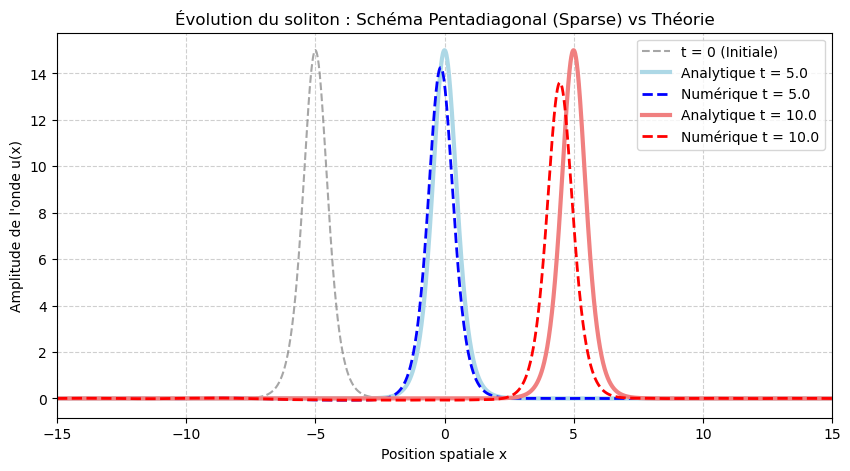

In [76]:
# ----------------------------------------
# Graphique Crank-Nikolson 
# ----------------------------------------


idx_mid = Nt // 2  # Moitié de la simulation
idx_fin = Nt - 1   # Dernier pas en temps
t_mid = Tf / 2     # Valeur physique du temps intermédiaire

plt.figure(figsize=(10, 5))

# Etat initial
plt.plot(x_num_sp, U_ex[0, :], '--', color='gray', alpha=0.7, label='t = 0 (Initiale)')

# Etat intermediaire
plt.plot(x_num_sp, U_ex[idx_mid, :], '-', color='lightblue', linewidth=3, label=f'Analytique t = {t_mid}')
plt.plot(x_num_sp, U_numerique_final_sp[idx_mid, :], '--', color='blue', linewidth=2, label=f'Numérique t = {t_mid}')

# Etat final
plt.plot(x_num_sp, U_ex[idx_fin, :], '-', color='lightcoral', linewidth=3, label=f'Analytique t = {Tf}')
plt.plot(x_num_sp, U_numerique_final_sp[idx_fin, :], '--', color='red', linewidth=2, label=f'Numérique t = {Tf}')

plt.xlabel("Position spatiale x")
plt.ylabel("Amplitude de l'onde u(x)")
plt.title("Évolution du soliton : Schéma Pentadiagonal (Sparse) vs Théorie")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(x_debut, x_fin)
plt.show()

# Animation

RuntimeError: Requested MovieWriter (ffmpeg) not available

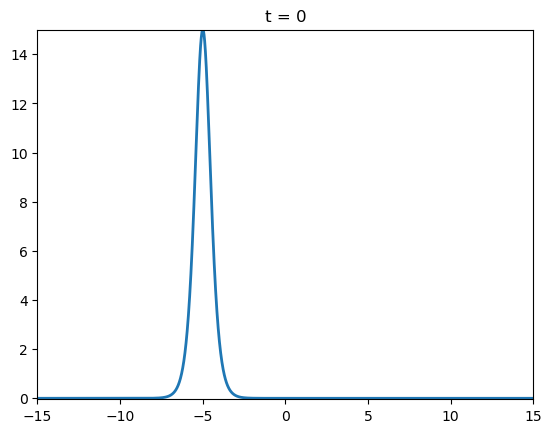

In [86]:

# Figure
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)

# Limites
ax.set_xlim(-15, 15)
ax.set_ylim(U_numerique_final_sp.min(), U_numerique_final_sp.max())

# Fonction d'animation
def update(i):
    line.set_data(x_num_sp, U_numerique_final_sp[i, :])
    ax.set_title(f"t = {i}")
    return line

# Animation
ani = FuncAnimation(fig, update, frames=Nt,interval=30)

HTML(ani.to_html5_video())

RuntimeError: Requested MovieWriter (ffmpeg) not available

Error in callback <function _draw_all_if_interactive at 0x000001F794A885E0> (for post_execute), with arguments args (),kwargs {}:


TypeError: sol_an() missing 3 required positional arguments: 'mu', 'c', and 'x0'

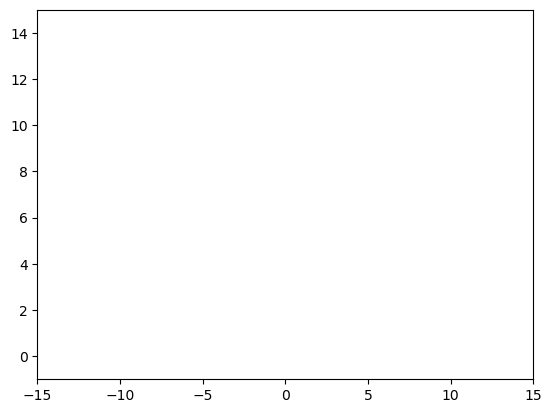

In [ ]:
# Figure
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)

ax.set_xlim(x_num_sp.min(), x_num_sp.max())
ax.set_ylim(-1, 15)

t = np.linspace(0, Tf, Nt)

def update2(i):
    y = sol_an(x_num_sp, t[i], eps, mu, c, x0)
    line.set_data(x_num_sp, y)
    ax.set_title(f"t = {t[i]}")
    return line,

ani = FuncAnimation(fig, update2, frames=len(t), interval=30)

HTML(ani.to_html5_video())